<a href="https://colab.research.google.com/github/Sanat1427/USL-LAB/blob/main/q1_29_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
data = pd.read_csv("Mall_Customers.csv")
print(data.head())
print(data.info())
print(data.isnull().sum())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Genre                  

In [2]:
X=data[["Annual Income (k$)","Spending Score (1-100)"]]

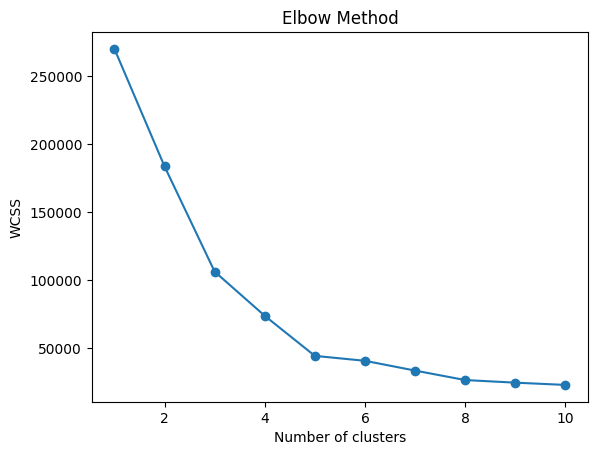

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title("Elbow Method")
plt.show()

In [4]:
kmeans=KMeans(n_clusters=5,random_state=42)
clusters=kmeans.fit_predict(X)
data['Cluster']=clusters

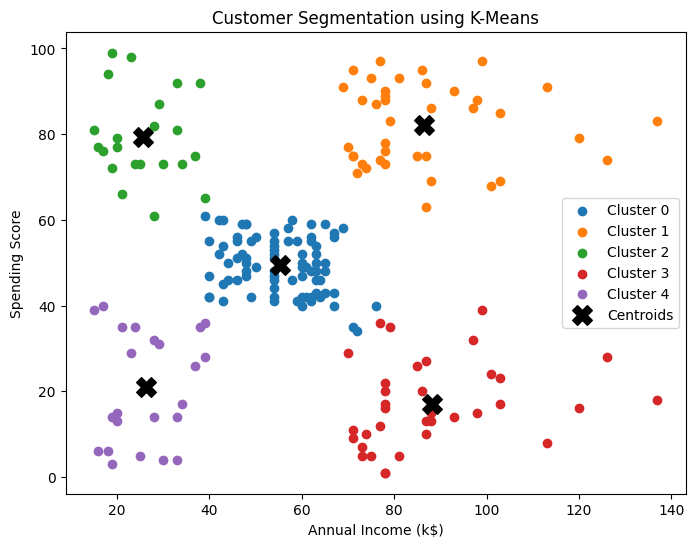

In [5]:
plt.figure(figsize=(8,6))
for i in range(5):
  plt.scatter(
      X.iloc[clusters == i,0],
      X.iloc[clusters == i,1],
      label=f'Cluster {i}'
  )
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()
